# 13. `dask`: Parallel Computations for Large Datasets

Some people think that large datasets or "big data" are mostly applied to machine learning and artificial intelligence fields. In atmospheric science, 

> Big data refers to data sets that are so voluminous and complex that traditional data processing application software is inadequate to deal with them.

Due to the long periods and finer grid resolutions of modern reanalysis data or model outputs, it takes huge amount of time and consumes large RAM if reading all the data values. For example, if we read and load the whole ERA5 geopotential files in DJF 1981-2020, 

```
hgt = xr.open_mfdataset( "/tsubaki_data/wtsai/PyAOS/era5_hgt_demo/*.nc",    
                           combine = "nested",
                           concat_dim = "time",                
                           parallel=True          
                         ).load()
hgt 
```

The process takes 7 minutes and 21 seconds, and consumes up to 110GB of RAM on our server. What worse, if executing the above code on a server without enough RAM, it can lead to system overload. You may see the following error message:

`MemoryError: Unable to allocate 52.2 GiB for an array with shape (365, 37, 721, 1440) and data type float32`

This error message appears because the data size has exceeded the RAM capacity. How should we avoid this situation?

## Dask Arrays

`Dask` is a flexible library for parallel computing in Python. It can scale up to operate on large datasets and perform computations that cannot fit into memory. `Dask` achieves this by breaking down large computations into smaller tasks, which are then executed in parallel. This can avoid consuming large amount of RAM. 

To understand the usage of dask, with demonstrate first with a 1000 × 4000 array size. 

**1. Numpy Array:**

In [1]:
import numpy as np

shape = (1000, 4000)
ones_np = np.ones(shape)
ones_np

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]], shape=(1000, 4000))

**2. Dask Array:**

In [2]:
import dask.array as da

ones = da.ones(shape)
ones

dask.array<ones_like, shape=(1000, 4000), dtype=float64, chunksize=(1000, 4000), chunktype=numpy.ndarray>

![](https://docs.dask.org/en/latest/_images/dask-array.svg)

Dask devides the entire array into sub-arrays named "chunk". In `dask`, we can specify the size of a chunk.

In [3]:
chunk_shape = (1000, 1000)
ones = da.ones(shape, chunks=chunk_shape)
ones

dask.array<ones_like, shape=(1000, 4000), dtype=float64, chunksize=(1000, 1000), chunktype=numpy.ndarray>

We can do some arithmetic calculations, such as multiplication and averaging.

In [4]:
ones_mean = (ones * ones[::-1, ::-1]).mean()
ones_mean

dask.array<mean_agg-aggregate, shape=(), dtype=float64, chunksize=(), chunktype=numpy.ndarray>

Following is the calculation procedure:

![](https://earth-env-data-science.github.io/_images/dask_arrays_16_0.png)

Dask allows computation of each chunk in each memory core, and finally combines all the computation of each chunk to a final result.  Dask integrates commonly-used functions in `numpy` and `xarray`, which is beneficial to processing climate data. Then how will `dask` help with large datasets? In the following sections, we will demonstrate two types of workflow that will leverage the usage of `dask` to elevate computation efficiency. 


## Dask Environment Setup

We add the following codes before we proceed to primary computation jobs. 

In [ ]:
from dask import delayed, compute
from dask.distributed import Client, LocalCluster

cluster = LocalCluster(n_workers=8, threads_per_worker=1, memory_limit='32GB')
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 8,Total memory: 238.42 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41601,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39193,Total threads: 1
Dashboard: http://127.0.0.1:35179/status,Memory: 29.80 GiB
Nanny: tcp://127.0.0.1:41927,


2026-06-17 16:57:27,654 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 5e34f35db7d577844d69ae3cc4811997 initialized by task ('rechunk-merge-rechunk-transfer-30e23485a5d9dc6b50d76456829430e6', 9, 0, 0, 9, 0, 0) executed on worker tcp://127.0.0.1:39847
2026-06-17 16:57:27,696 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle ad17fceab0a9667fde4409b8c5e99b50 initialized by task ('rechunk-merge-rechunk-transfer-30e23485a5d9dc6b50d76456829430e6', 9, 0, 2, 9, 0, 2) executed on worker tcp://127.0.0.1:42731
2026-06-17 16:57:27,700 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 85a7cb0bf37532f1e3528d58e0de9c01 initialized by task ('rechunk-merge-rechunk-transfer-30e23485a5d9dc6b50d76456829430e6', 9, 0, 1, 9, 0, 1) executed on worker tcp://127.0.0.1:39819
2026-06-17 16:57:27,938 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle ad17fceab0a9667fde4409b8c5e99b50 deactivated due to stimulus 'task-finished-1781733447.935946'
2026-06-17 16:57:27,963 - dis

- `LocalCluster`: Used to start multiple workers on the local machine for parallel computation
- `Client`: Connects to the scheduler and handles communication between your Python session and the cluster. Every computation job is submitted to the workers through the client.
- `cluster = LocalCluster(n_workers=32, threads_per_worker=1, memory_limit=0)`: Creates a local cluster where each worker runs on a single thread. Our server, for example, has 64 CPU (32 physical cores, you can see from `bpytop` on Linux) — one worker per physical core works best for numerical computations. The memory limit can be set to 0, meaning no restriction. Be cautious: if the dataset is too large or the workflow is poorly designed, this may overload the available RAM. In practice, you can set the memory limit explicitly (e.g., `"4GB"`, `"8GB"`, `"16GB"`) to protect your system.
- `client = Client(cluster)`: Initializes a client object that communicates with the cluster. This ensures all Dask operations (e.g., loading large NetCDF/GRIB files with xarray, or delayed computations) are distributed to the workers via the scheduler.

There is also a link to the Client Dashboard. You can click to monitor your LocalCluster in real time.

![](https://tutorial.dask.org/_images/distributed-overview.png)

## Large Climate Dataset Processing

In Unit 2, we introduced the `parallel=True` option in `xarray.open_mfdataset`. This option allows `xarray` to read the file using `dask`.  

In [6]:
import xarray as xr

hgt = (xr.open_mfdataset( "/tsubaki_data/wtsai/PyAOS/era5_hgt_demo/*.nc",    # 檔案名稱
                           combine = "nested",
                           concat_dim = "time",   # 以時間維度串接資料               
                           parallel=True          # 運用dask平行運算，提高運算效率
                         )
         .hgt)     # 將資料持久化到記憶體中，避免重複計算
hgt 

<xarray.DataArray 'hgt' (time: 14440, level: 2, latitude: 361, longitude: 720)> Size: 60GB
dask.array<concatenate, shape=(14440, 2, 361, 720), dtype=float64, chunksize=(1, 1, 361, 720), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 116kB 1981-12-01 ... 2021-02-28T18:00:00
  * level      (level) int32 8B 200 850
  * latitude   (latitude) float32 1kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude  (longitude) float32 3kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
Attributes:
    standard_name:  geopotential_height
    long_name:      geopotential height
    units:          m

At this point, `hgt` is a **Dask-backed DataArray**, not a full in-memory NumPy array. At this point, no actual data is read into RAM yet. The DataArray only stores metadata: dimensions, coordinates, data type, chunking info. Hence, the `u` array is very small (only a few MB regardless of how big your NetCDF files). 

Although xarray automatically chunks the dataset when using `xr.open_mfdataset()`, you can rechunk manually as follow:


In [7]:
from xarray.groupers import TimeResampler

hgt = hgt.chunk({'time': 360, 'level':1, 'latitude':361,'longitude':360})
hgt

<xarray.DataArray 'hgt' (time: 14440, level: 2, latitude: 361, longitude: 720)> Size: 60GB
dask.array<rechunk-merge, shape=(14440, 2, 361, 720), dtype=float64, chunksize=(360, 1, 361, 360), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 116kB 1981-12-01 ... 2021-02-28T18:00:00
  * level      (level) int32 8B 200 850
  * latitude   (latitude) float32 1kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude  (longitude) float32 3kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
Attributes:
    standard_name:  geopotential_height
    long_name:      geopotential height
    units:          m

Manual rechunking is particularly useful when the dataset is very large and the automatic chunking produces too many small chunks, which can lead to high scheduling overhead in Dask.

Practical guidelines for chunk sizing:
- Aim for chunk sizes roughly 50–200 MB each. This is large enough to reduce overhead but small enough to fit in RAM comfortably.
- Avoid having too many chunks per dimension (e.g., hundreds or thousands), because Dask has to manage each chunk as a separate task, which can slow down the computation.

Read more details on how to choose good chunk sizes [here](https://blog.dask.org/2021/11/02/choosing-dask-chunk-sizes?utm_source=xarray-docs).

### `.compute()`

`compute()` will triger the computation and exeute task graphs. The final results will be loaded into RAM.  Therefore, it is a good practice to slice,  subset, or reduce your datasets before calling `.compute()`, especially when working with large NetCDF or GRIB files, to avoid memory overload.


In [8]:
hgt_DayClm = hgt.groupby("time.dayofyear").mean("time")
hgt_DayClm

<xarray.DataArray 'hgt' (dayofyear: 92, level: 2, latitude: 361, longitude: 720)> Size: 383MB
dask.array<transpose, shape=(92, 2, 361, 720), dtype=float64, chunksize=(92, 1, 361, 360), chunktype=numpy.ndarray>
Coordinates:
  * dayofyear  (dayofyear) int64 736B 1 2 3 4 5 6 7 ... 361 362 363 364 365 366
  * level      (level) int32 8B 200 850
  * latitude   (latitude) float32 1kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude  (longitude) float32 3kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
Attributes:
    standard_name:  geopotential_height
    long_name:      geopotential height
    units:          m

The whole array is reduced to only 364.88 MB. Now we can trigger the computation and execute task graphs and load into a DataArray. 

In [9]:
hgt_DayClm_computed = hgt_DayClm.compute()
hgt_DayClm_computed

<xarray.DataArray 'hgt' (dayofyear: 92, level: 2, latitude: 361, longitude: 720)> Size: 383MB
array([[[[10930.1159184 , 10930.1159184 , 10930.1159184 , ...,
          10930.1159184 , 10930.1159184 , 10930.1159184 ],
         [10929.4758632 , 10929.47582515, 10929.47086723, ...,
          10929.45623411, 10929.47088669, 10929.48070794],
         [10929.41516135, 10929.42975178, 10929.45415206, ...,
          10929.40539312, 10929.41519297, 10929.39077232],
         ...,
         [11172.42958887, 11172.45400705, 11172.42486827, ...,
          11172.43436912, 11172.43925759, 11172.42472012],
         [11172.14931586, 11172.14929319, 11172.14442839, ...,
          11172.15901549, 11172.14440686, 11172.15408012],
         [11172.07833952, 11172.07833952, 11172.07833952, ...,
          11172.07833952, 11172.07833952, 11172.07833952]],

        [[ 1307.23130211,  1307.23130211,  1307.23130211, ...,
           1307.23130211,  1307.23130211,  1307.23130211],
         [ 1304.56057706,  1304.56058476,  1304.56553757, ...,
           1304.46800536,  1304.52163945,  1304.54595003],
         [ 1302.13266436,  1302.16685503,  1302.17177931, ...,
           1302.12769043,  1302.1130586 ,  1302.12288827],
...
          11180.23711608, 11180.2565461 , 11180.23696553],
         [11179.84676047, 11179.82726324, 11179.82720626, ...,
          11179.8663082 , 11179.8663082 , 11179.86629267],
         [11179.59278188, 11179.59278188, 11179.59278188, ...,
          11179.59278188, 11179.59278188, 11179.59278188]],

        [[ 1309.9335785 ,  1309.9335785 ,  1309.9335785 , ...,
           1309.9335785 ,  1309.9335785 ,  1309.9335785 ],
         [ 1306.23651483,  1306.25598439,  1306.27548291, ...,
           1306.15861455,  1306.19754518,  1306.21705632],
         [ 1303.04599646,  1303.04586108,  1303.08483245, ...,
           1302.94848839,  1302.9095922 ,  1303.00707226],
         ...,
         [ 1278.33943448,  1278.3588645 ,  1278.3588645 , ...,
           1278.24213674,  1278.22263951,  1278.28112984],
         [ 1277.38394127,  1277.36448406,  1277.34491962, ...,
           1277.32559471,  1277.36449242,  1277.36449242],
         [ 1276.01912283,  1276.01912283,  1276.01912283, ...,
           1276.01912283,  1276.01912283,  1276.01912283]]]],
      shape=(92, 2, 361, 720))
Coordinates:
  * dayofyear  (dayofyear) int64 736B 1 2 3 4 5 6 7 ... 361 362 363 364 365 366
  * level      (level) int32 8B 200 850
  * latitude   (latitude) float32 1kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude  (longitude) float32 3kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
Attributes:
    standard_name:  geopotential_height
    long_name:      geopotential height
    units:          m

The whole computation time takes less than one and half minute on our server, much less than the computation time required by simply reading and loading the whole data values. 

### `.persist()`

Every `.compute()` triggers the *entire* task graph from beginning: reading the original NetCDF/GRIB files from disk, chunking the data, performing intermediate computations, and producing the final results. If you plan to use a intermediate product multiple times, you can **persist** it before the following calculations. For example, we now calculate the $Z_{200}$ anomaly:

In [10]:
hgtDay = hgt.coarsen(time=4,coord_func='min').mean() # Convert to daily mean 
za200 = ((hgtDay.groupby("time.dayofyear") - hgt_DayClm_computed).sel(level=200)
                .chunk({'time': 90, 'latitude':180,'longitude':240}))
za200 = za200.persist()
za200

/data/wtsai/micromamba/p312/lib/python3.12/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 377.74 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


<xarray.DataArray 'hgt' (time: 3610, latitude: 361, longitude: 720)> Size: 8GB
dask.array<rechunk-p2p, shape=(3610, 361, 720), dtype=float64, chunksize=(90, 180, 240), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 29kB 1981-12-01 1981-12-02 ... 2021-02-28
  * latitude   (latitude) float32 1kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude  (longitude) float32 3kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
    level      int32 4B 200
    dayofyear  (time) int64 29kB dask.array<chunksize=(90,), meta=np.ndarray>
Attributes:
    standard_name:  geopotential_height
    long_name:      geopotential height
    units:          m

The `.persist()` triggers computation of parts of the task graph and stores the resulting chunks in the *workers' memory (RAM)*, rather than returning them to the main Python session. We see that `za200` remains a dask array, but the dask graph has been reduced to 1. Subsequent computations that depend on the persisted data will directly use the in-memory chunks, avoiding repeated reading and intermediate computations.

```{caution}
Only persist the intermediate data whose size fits within the workers' total memory. 
```

Finally, we choose a day to plot the anomaly map. Note that the plot function will automatically triger computation without `.compute()`. 

Text(0.5, 1.0, '$Z_{200}$ Anomaly (2012-01-01)')

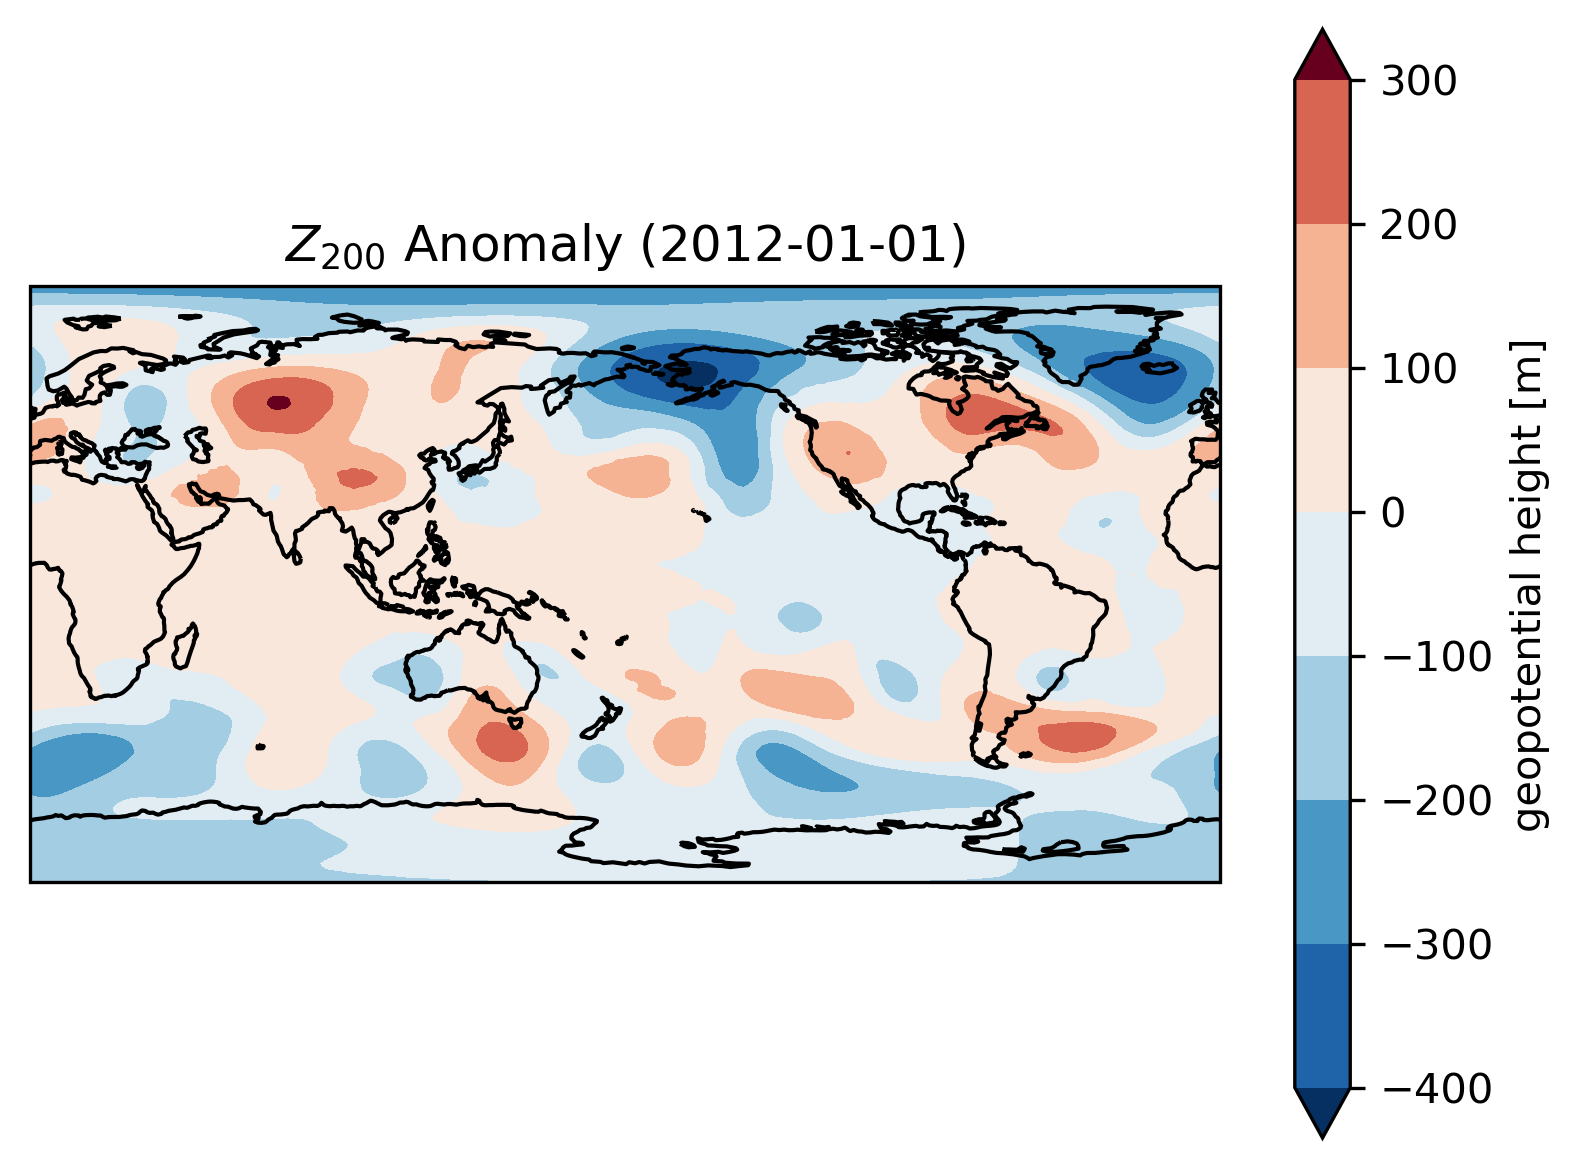

In [11]:
import matplotlib as mpl
from matplotlib import pyplot as plt
from cartopy import crs as ccrs   
mpl.rcParams['figure.dpi'] = 300

fig, ax = plt.subplots(1,1, 
                       subplot_kw=dict(projection=ccrs.PlateCarree(central_longitude=180)))                        
za200.sel(time='2012-01-01').plot.contourf(x='longitude', y='latitude', 
                        ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu_r', extend='both')
ax.coastlines()
ax.set_title(r'$Z_{200}$ Anomaly (2012-01-01)')

**Example 1**: Plot the $Z_{200}$ regression maps on to RMM1 and RMM2. 

**Step 1**: Read MJO data from the IRI data library. 

In [12]:
import pandas as pd

# Read MJO data
mjo_ds = xr.open_dataset('http://iridl.ldeo.columbia.edu/SOURCES/.BoM/.MJO/.RMM/dods',
                         engine='netcdf4',
                         decode_times=False).rename({'T':'time'})
T = mjo_ds.time.values
mjo_ds['time'] = pd.date_range("1974-06-01", periods=len(T))  # The begining date of the RMM index is 1974-06-01
mjo_ds = mjo_ds.sel(time=za200.time).chunk({'time': 360})  # Align the time dimension of mjo_ds with za200
mjo_ds

syntax error, unexpected WORD_WORD, expecting ';' or ','
context: Attributes { T { String standard_name "time"; Float32 pointwidth 1.0; String calendar "standard"; Int32 expires 1781654400; Int32 gridtype 0; String units "julian_day"; } amplitude { Int32 expires 1781654400; String units "unitless"; Float32 missing_value 9.99999962E35; } phase { Int32 expires 1781654400; String units "unitless"; Float32 missing_value 999.0; } RMM1 { Int32 expires 1781654400; String units "unitless"; Float32 missing_value 9.99999962E35; } RMM2 { Int32 expires 1781654400; String units "unitless"; Float32 missing_value 9.99999962E35; }NC_GLOBAL { URL Wheeler and Hendon^ (2004) Monthly Weather Review article "http://journals.ametsoc.org/doi/abs/10.1175/1520-0493(2004)132%3C1917:AARMMI%3E2.0.CO;2"; String description "Real-time Multivariate MJO Index (with components of interannual variability removed)"; URL summary from BoM "http://www.bom.gov.au/climate/mjo/"; URL data source "http://www.bom.gov.au/climate

<xarray.Dataset> Size: 116kB
Dimensions:    (time: 3610)
Coordinates:
  * time       (time) datetime64[ns] 29kB 1981-12-01 1981-12-02 ... 2021-02-28
    level      int32 4B 200
    dayofyear  (time) int64 29kB dask.array<chunksize=(360,), meta=np.ndarray>
Data variables:
    amplitude  (time) float32 14kB dask.array<chunksize=(360,), meta=np.ndarray>
    phase      (time) float32 14kB dask.array<chunksize=(360,), meta=np.ndarray>
    RMM1       (time) float32 14kB dask.array<chunksize=(360,), meta=np.ndarray>
    RMM2       (time) float32 14kB dask.array<chunksize=(360,), meta=np.ndarray>

**Step 2**: Calculate the regression coefficient $\mathbf{A}$ using the following equation:

$$\mathbf{A} = \dfrac{\mathrm{Cov}(X,Y)}{\mathrm{Cov}(X,X)}$$

where $Y$ is predictand data (in this case, RMM index), and $X$ is predictor matrix (in this case, `za`).

In [13]:
z_rmm1_slope = xr.cov(za200, mjo_ds.RMM1, dim='time') / xr.cov(mjo_ds.RMM1, mjo_ds.RMM1, dim='time')
z_rmm2_slope = xr.cov(za200, mjo_ds.RMM2, dim='time') / xr.cov(mjo_ds.RMM2, mjo_ds.RMM2, dim='time')

syntax error, unexpected WORD_WORD, expecting ';' or ','
context: Attributes { T { String standard_name "time"; Float32 pointwidth 1.0; String calendar "standard"; Int32 expires 1781654400; Int32 gridtype 0; String units "julian_day"; } amplitude { Int32 expires 1781654400; String units "unitless"; Float32 missing_value 9.99999962E35; } phase { Int32 expires 1781654400; String units "unitless"; Float32 missing_value 999.0; } RMM1 { Int32 expires 1781654400; String units "unitless"; Float32 missing_value 9.99999962E35; } RMM2 { Int32 expires 1781654400; String units "unitless"; Float32 missing_value 9.99999962E35; }NC_GLOBAL { URL Wheeler and Hendon^ (2004) Monthly Weather Review article "http://journals.ametsoc.org/doi/abs/10.1175/1520-0493(2004)132%3C1917:AARMMI%3E2.0.CO;2"; String description "Real-time Multivariate MJO Index (with components of interannual variability removed)"; URL summary from BoM "http://www.bom.gov.au/climate/mjo/"; URL data source "http://www.bom.gov.au/climate

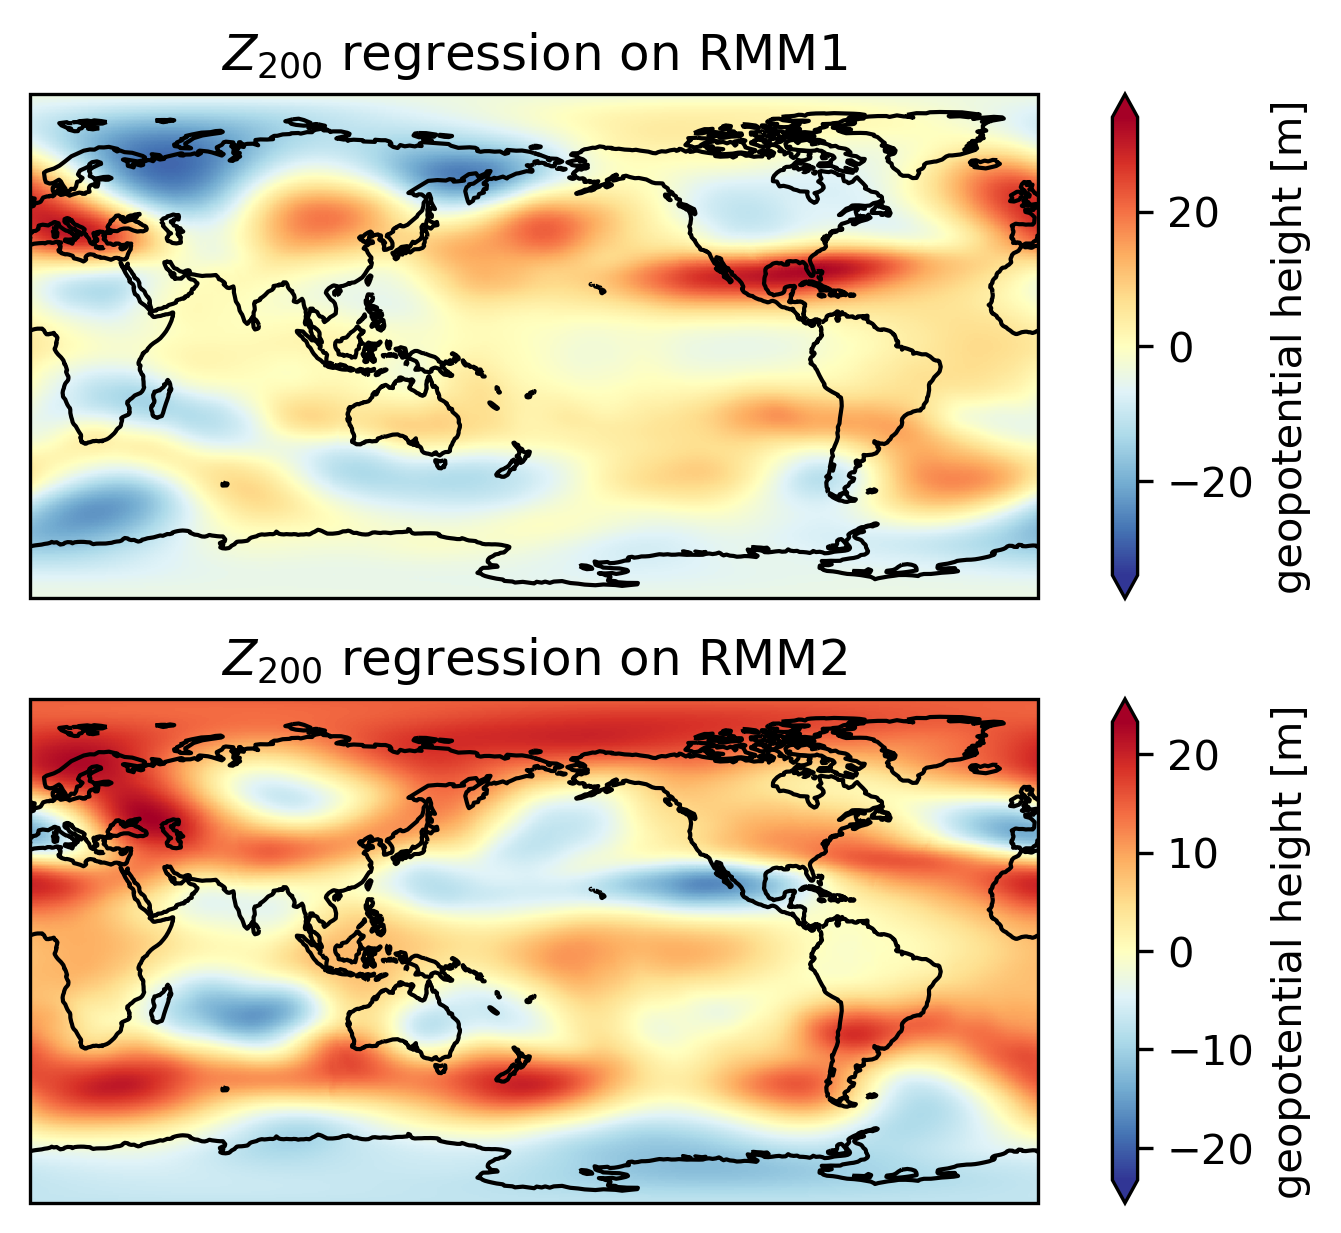

In [14]:
fig, ax = plt.subplots(2,1,
                       subplot_kw=dict(projection=ccrs.PlateCarree(central_longitude=180)))   

z_rmm1_slope.plot(x='longitude', y='latitude', ax=ax[0], cmap='RdYlBu_r', extend='both')
z_rmm2_slope.plot(x='longitude', y='latitude', ax=ax[1], cmap='RdYlBu_r', extend='both')

for i in range(2):
    ax[i].coastlines()
    ax[i].set_title(r'$Z_{200}$ regression on '+ f'RMM{i+1}')

 ### Takeaway

In this example, we practice the following workflow:
1. Open data lazily with Dask  
2. Decide chunking strategy  
3. Use `.persist()` for frequently reused core variables (`za200`) 
4. Use `.compute()` only when results are truly needed  

## Incorporating `flox` with `dask`

`flox` mainly provides strategies for fast `GroupBy` reductions with `dask.array`. 

**Example 2:** Calculate the composite mean of $Z_{200}$ for each MJO phase. 

In [15]:
from flox.xarray import xarray_reduce 

mjo_phase = mjo_ds.phase.compute()

z200_mjo_comp = xarray_reduce(za200,
                              mjo_phase, # Should be given explcitly, therefore we compute and load it.
                              func='mean',
                              dim='time',
                              isbin=False,
                              ) 
z200_mjo_comp = z200_mjo_comp.compute()
z200_mjo_comp 

syntax error, unexpected WORD_WORD, expecting ';' or ','
context: Attributes { T { String standard_name "time"; Float32 pointwidth 1.0; String calendar "standard"; Int32 expires 1781654400; Int32 gridtype 0; String units "julian_day"; } amplitude { Int32 expires 1781654400; String units "unitless"; Float32 missing_value 9.99999962E35; } phase { Int32 expires 1781654400; String units "unitless"; Float32 missing_value 999.0; } RMM1 { Int32 expires 1781654400; String units "unitless"; Float32 missing_value 9.99999962E35; } RMM2 { Int32 expires 1781654400; String units "unitless"; Float32 missing_value 9.99999962E35; }NC_GLOBAL { URL Wheeler and Hendon^ (2004) Monthly Weather Review article "http://journals.ametsoc.org/doi/abs/10.1175/1520-0493(2004)132%3C1917:AARMMI%3E2.0.CO;2"; String description "Real-time Multivariate MJO Index (with components of interannual variability removed)"; URL summary from BoM "http://www.bom.gov.au/climate/mjo/"; URL data source "http://www.bom.gov.au/climate

<xarray.DataArray 'hgt' (phase: 8, latitude: 361, longitude: 720)> Size: 17MB
array([[[-16.21638403, -16.21638403, -16.21638403, ..., -16.21638403,
         -16.21638403, -16.21638403],
        [-16.45938656, -16.46766909, -16.48030671, ..., -16.41065878,
         -16.42699937, -16.44483857],
        [-16.7485588 , -16.78833751, -16.82949572, ..., -16.67295205,
         -16.69589743, -16.71839463],
        ...,
        [  2.31688282,   2.31320739,   2.31765814, ...,   2.32929449,
           2.32026278,   2.31485393],
        [  1.97374334,   1.974563  ,   1.97899917, ...,   1.97284541,
           1.9725364 ,   1.97309874],
        [  1.67238445,   1.67238445,   1.67238445, ...,   1.67238445,
           1.67238445,   1.67238445]],

       [[-24.49535107, -24.49535107, -24.49535107, ..., -24.49535107,
         -24.49535107, -24.49535107],
        [-24.97210485, -24.96997786, -24.96206509, ..., -24.98547217,
         -24.98275423, -24.97603681],
        [-25.42430556, -25.41441067, -25.40006341, ..., -25.44232578,
         -25.43940424, -25.43189563],
...
        [-10.59416143, -10.59977146, -10.60657966, ..., -10.57590536,
         -10.58332785, -10.58461782],
        [-10.31923195, -10.32054669, -10.3296241 , ..., -10.30287466,
         -10.30584526, -10.31512333],
        [-10.06235151, -10.06235151, -10.06235151, ..., -10.06235151,
         -10.06235151, -10.06235151]],

       [[ 24.30788792,  24.30788792,  24.30788792, ...,  24.30788792,
          24.30788792,  24.30788792],
        [ 22.83123093,  22.82040345,  22.80702291, ...,  22.8951205 ,
          22.87123882,  22.84709093],
        [ 21.38680558,  21.36552436,  21.33095164, ...,  21.48413351,
          21.46037481,  21.41499076],
        ...,
        [  5.42952589,   5.43979072,   5.45225821, ...,   5.39877403,
           5.41316294,   5.41719153],
        [  5.05720133,   5.07215323,   5.08047306, ...,   5.04045871,
           5.03958773,   5.04973597],
        [  4.71828462,   4.71828462,   4.71828462, ...,   4.71828462,
           4.71828462,   4.71828462]]], shape=(8, 361, 720))
Coordinates:
  * phase      (phase) float32 32B 1.0 2.0 3.0 4.0 5.0 6.0 7.0 8.0
  * latitude   (latitude) float32 1kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude  (longitude) float32 3kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
    level      int32 4B 200
Attributes:
    standard_name:  geopotential_height
    long_name:      geopotential height
    units:          m

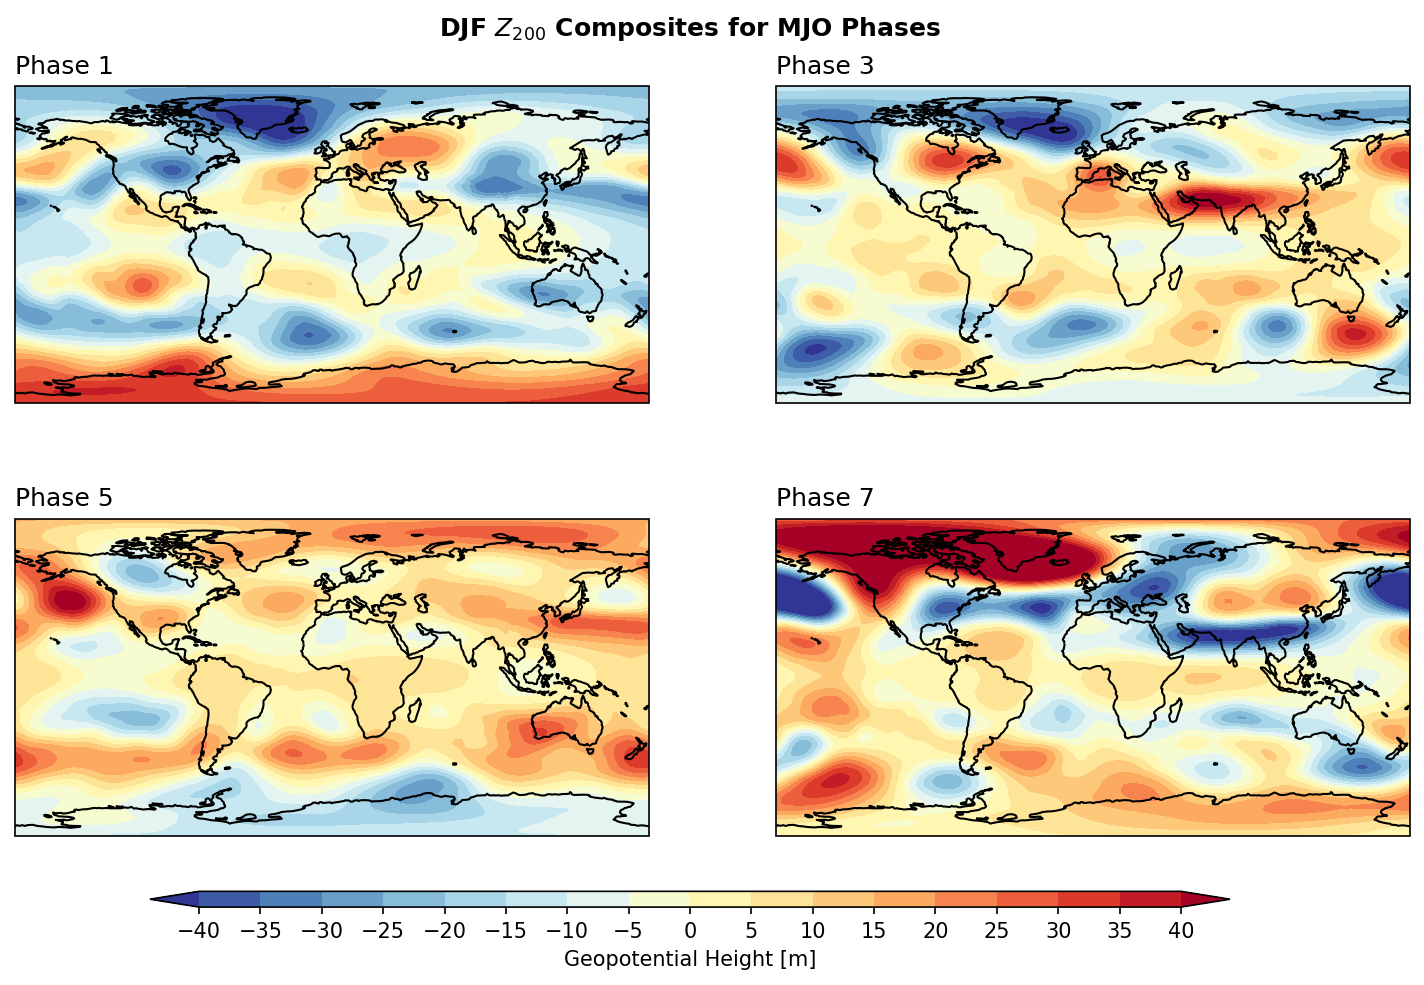

In [16]:
import matplotlib as mpl
from matplotlib import pyplot as plt
import cmaps
from cartopy import crs as ccrs   
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

mpl.rcParams['figure.dpi'] = 150

fig, axes = plt.subplots(2,2, 
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         figsize=(12,7))
ax = axes.flatten()
lon_formatter = LONGITUDE_FORMATTER
lat_formatter = LATITUDE_FORMATTER

clevs = range(-40,45,5)

porder = [0,2,4,6,1,3,5,7]

for i in [1,3,5,7]: 
    cf = (z200_mjo_comp[i,:,:].plot.contourf(x='longitude',y='latitude', 
                                             ax=ax[int(i/2)],
                                             levels=clevs,
                                             add_colorbar=False,
                                             cmap='RdYlBu_r', 
                                             extend='both',
                                             transform=ccrs.PlateCarree()))
    
    ax[int(i/2)].coastlines()
    ax[int(i/2)].xaxis.set_major_formatter(lon_formatter)
    ax[int(i/2)].yaxis.set_major_formatter(lat_formatter)
    ax[int(i/2)].set_xlabel(' ')
    ax[int(i/2)].set_ylabel(' ')
    ax[int(i/2)].set_title(' ')
    ax[int(i/2)].set_title('Phase '+str(i), loc='left')
    
# Add a colorbar axis at the bottom of the graph
cbar_ax = fig.add_axes([0.2, 0.07, 0.6, 0.015])
# Draw the colorbar 將colorbar畫在cbar_ax這個軸上。
cbar = fig.colorbar(cf, cax=cbar_ax,
                    orientation='horizontal',
                    ticks=clevs,
                    label=r'Geopotential Height [m]')  

plt.subplots_adjust(hspace=0.15)
plt.suptitle('DJF $Z_{200}$ Composites for MJO Phases',y=0.92,size='large',weight='bold')
plt.show()    

## Loops with Parallel Computation

Sometimes, intrinsic functions cannot directly be applied to our analysis procedure. Therefore, we have to loop over different index for several times. We can wrap this workflow into a function, and then run the function across a loop in **parallel** using Dask.  For example, if we have 8 iterations in a loop and 8 available cores (workers), Dask can distribute each iteration to a separate core. In ideal conditions, this can reduce the total loop runtime roughly to the time of a **single iteration**, since the 8 iterations are computed simultaneously. This approach allows us to take full advantage of multiple cores without manually managing threads or processes.

### Parallel Procedure (ONGOING EDITTING!!!)

Since each phase composite is **independent**, we can parallelize the loop with Dask. The idea is:

1. Wrap the composite calculation for one phase into a function.
2. Use `dask.delayed` to build tasks for all eight phases without executing them immediately.
3. Call `compute()` once, letting Dask schedule and run all phase composites in parallel across multiple workers.

The `@delayed` decorator before the `compute_phase_composite()` function is used to turn a normal Python function into a lazy task. Normally, when you call a function in Python, it executes immediately and returns a result. But with `@delayed`, the function call does **not** execute right away. Instead, it returns a **Delayed object** that represents a task in a computation graph.  

When you collect many Delayed objects (e.g., inside a loop), Dask can build a full task graph. The actual computation happens only when you explicitly call `.compute()` (or `dask.compute(...)`), at which point Dask will schedule the tasks across multiple workers and run them in parallel.  

In [ ]:
@delayed
def bootstrap_phase(za_anom, mjo_phase, phase, nboot=500):
    data = za_anom.where(mjo_phase == phase, drop=True).compute()
    n = data.sizes['time']
    boot_mean = xr.concat([
        data.isel(time=np.random.randint(0, n, n)).mean('time')
        for _ in range(nboot)
    ], dim='bootstrap')
    low = boot_mean.quantile(0.025, 'bootstrap')
    high = boot_mean.quantile(0.975, 'bootstrap')
    return (low > 0) | (high < 0)

tasks = [bootstrap_phase(za200, mjo_phase, p) for p in range(1, 9)]
sig_masks = compute(*tasks)

## Summary: When to use Dask? 

**Use Dask:**. 

- When you have large datasets that don’t fit into memory on a single machine.  

- When you need to perform parallel computations, such as big data analysis.  

**Avoid Dask:**

- When you have small datasets that can be processed efficiently on a single machine.

- When you don’t need parallel processing, as the overhead of managing a distributed computing environment may not be worth the benefits.

- When you need to debug or troubleshoot problems, as distributed computing environments can be challenging for debugging. If the problem is complex, using Dask may make debugging more difficult.

